# Notebook 21 - MATLAB-style alpha and mask pipeline

Goal:

1. Use the MATLAB-style `dohough + weighted_median` alpha estimator instead of the current selected-line alpha.
2. Port the MATLAB mask pipeline from `filter_usimage.m` / `get_fasMask.m` closely enough to see whether the remaining alpha discrepancy comes from the mask.

We know from notebook 20:

- `abs(current alpha)` helps but is still not enough.
- `dohough + weighted_median` on the current Python mask is much closer.

This notebook now asks:

**What happens when the mask is also made more MATLAB-like?**

## Confirmed assumptions

You confirmed:

- MATLAB used the same video.
- MATLAB used default parameters from the GitHub MATLAB folder.
- ROI was selected manually, so small ROI differences are expected.

The default MATLAB settings used here are:

- fascicle Frangi scale range `[1, 2]`
- aponeurosis Frangi scale range `[18, 20]`
- adaptive threshold sensitivity `0.5`
- fascicle Hough range `[8, 80]`
- `npeaks = 10`, `thetares = 1`, `rhores = 1`

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

%load_ext autoreload
%autoreload 2

current = Path.cwd()
if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import json
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage

from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    get_nested,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough, fascicle_ellipse_mask

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def sin_deg(x):
    return np.sin(np.deg2rad(x))

def metric_table(named_pairs):
    rows = []
    for name, ref, est in named_pairs:
        row = {"comparison": name}
        row.update(compute_metrics(ref, est))
        rows.append(row)
    return pd.DataFrame(rows)

def normalize_float01(image):
    arr = np.asarray(image, dtype=np.float64)
    lo = np.nanmin(arr)
    hi = np.nanmax(arr)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(arr, dtype=np.float64)
    return (arr - lo) / (hi - lo)

def polyval(coefficients, x):
    return np.polyval(np.asarray(coefficients, dtype=float), np.asarray(x, dtype=float))

## Load MATLAB and Python references

In [3]:
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY_TIMTRACK = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
geofeature_entries = list(get_nested(mat, "Fdat.geofeatures"))
py_tim = dict(np.load(PY_TIMTRACK, allow_pickle=True))

with ROI_PATH.open() as handle:
    rois = json.load(handle)

cap = cv2.VideoCapture(str(VIDEO_PATH))
ok, frame0 = cap.read()
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
if not ok:
    raise RuntimeError("Could not read first video frame")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

n = min(len(matlab_geo["alpha_deg"]), len(py_tim["fascicle_angle_deg"]), frame_count)
frames = np.arange(n, dtype=int)

matlab_alpha = matlab_geo["alpha_deg"][:n]
current_alpha = np.asarray(py_tim["fascicle_angle_deg"], dtype=float)[:n]

nb20_cache = OUT_DIR / "notebook20_ported_dohough_current_mask_arrays.npz"
if nb20_cache.exists():
    nb20 = np.load(nb20_cache)
    current_mask_dohough_alpha = nb20["ported_alpha"][:n]
else:
    current_mask_dohough_alpha = np.full(n, np.nan)

print("Video:", frame0_gray.shape, "frames:", frame_count, "fps:", fps)
print("Aligned n:", n)
print("ROIs:", rois)
print("Loaded notebook 20 dohough cache:", nb20_cache.exists())

Video: (562, 706) frames: 2667 fps: 33.341
Aligned n: 2666
ROIs: {'superficial': [15, 21, 690, 42], 'deep': [16, 298, 689, 76], 'fascicle': [17, 65, 686, 226]}
Loaded notebook 20 dohough cache: True


## Notebook-local ports of MATLAB mask helpers

These functions are intentionally kept in the notebook first. The only known approximation here is MATLAB's `imbinarize(..., 'adaptive')`; this notebook uses a local-mean adaptive threshold with sensitivity `0.5`, which is the default MATLAB setting used by the TimTrack parameters.

In [4]:
DEFAULTS = {
    "apo_sigma": 10.0,
    "apo_th": 0.5,
    "apo_filtfac": 1.0,
    "apo_maxlengthratio": 0.9,
    "apo_super_cut": (0.05, 0.40),
    "apo_deep_cut": (0.65, 0.95),
    "apo_frangi_scale_range": (18.0, 20.0),
    "apo_frangi_scale_ratio": 1.0,
    "fas_th": 0.5,
    "fas_frangi_scale_range": (1.0, 2.0),
    "fas_frangi_scale_ratio": 1.0,
    "black_white": False,
    "apomargin": 20,
    "napo": 10,
    "nextrap": 5,
    "fillgap": 50,
    "hough_angle_range": (8.0, 80.0),
    "npeaks": 10,
    "thetares": 1.0,
    "rhores": 1.0,
}

def matlab_apox(width):
    return np.rint(
        np.linspace(
            DEFAULTS["apomargin"],
            width - DEFAULTS["apomargin"],
            DEFAULTS["napo"],
        )
    ).astype(int)

def hessian2d_matlabish(image, sigma):
    # Fast diagnostic approximation of MATLAB Hessian2D. The explicit MATLAB
    # derivative kernels are very slow at sigma 18-20 in pure Python, so this
    # uses scipy's Gaussian derivative implementation with replicate-like edges.
    image = np.asarray(image, dtype=np.float64)
    dxx = ndimage.gaussian_filter(image, sigma=sigma, order=(2, 0), mode="nearest")
    dxy = ndimage.gaussian_filter(image, sigma=sigma, order=(1, 1), mode="nearest")
    dyy = ndimage.gaussian_filter(image, sigma=sigma, order=(0, 2), mode="nearest")
    return dxx, dxy, dyy

def eig2image_matlabish(dxx, dxy, dyy):
    tmp = np.sqrt((dxx - dyy) ** 2 + 4 * dxy**2)
    v2x = 2 * dxy
    v2y = dyy - dxx + tmp

    mag = np.sqrt(v2x**2 + v2y**2)
    mask = mag != 0
    v2x = np.where(mask, v2x / np.where(mask, mag, 1), v2x)
    v2y = np.where(mask, v2y / np.where(mask, mag, 1), v2y)

    v1x = -v2y
    v1y = v2x

    mu1 = 0.5 * (dxx + dyy + tmp)
    mu2 = 0.5 * (dxx + dyy - tmp)

    check = np.abs(mu1) > np.abs(mu2)
    lambda1 = np.where(check, mu2, mu1)
    lambda2 = np.where(check, mu1, mu2)
    ix = np.where(check, v2x, v1x)
    iy = np.where(check, v2y, v1y)
    return lambda1, lambda2, ix, iy

def frangi_filter_2d_matlabish(
    image,
    scale_range=(1.0, 2.0),
    scale_ratio=1.0,
    beta_one=0.5,
    beta_two=15.0,
    black_white=False,
):
    image = np.asarray(image, dtype=np.float64)
    sigmas = np.arange(scale_range[0], scale_range[1] + 1e-9, scale_ratio)
    sigmas = np.sort(sigmas)

    beta = 2 * beta_one**2
    c = 2 * beta_two**2

    best = np.zeros_like(image, dtype=np.float64)
    for sigma in sigmas:
        dxx, dxy, dyy = hessian2d_matlabish(image, float(sigma))
        dxx *= sigma**2
        dxy *= sigma**2
        dyy *= sigma**2

        lambda1, lambda2, _, _ = eig2image_matlabish(dxx, dxy, dyy)
        lambda1 = np.where(lambda1 == 0, np.finfo(float).eps, lambda1)

        rb = (lambda1 / lambda2) ** 2
        s2 = lambda1**2 + lambda2**2
        filtered = np.exp(-rb / beta) * (1 - np.exp(-s2 / c))

        if black_white:
            filtered = np.where(lambda1 < 0, 0, filtered)
        else:
            filtered = np.where(lambda1 > 0, 0, filtered)

        best = np.maximum(best, filtered)

    return best

def adaptive_imbinarize_matlabish(image, sensitivity=0.5, block_size=None):
    image01 = normalize_float01(image)
    if block_size is None:
        # MATLAB adaptthresh chooses a local window from image size.
        # This odd scalar window is a practical approximation.
        block_size = int(2 * np.floor(min(image01.shape) / 16) + 1)
        block_size = max(15, block_size)
    if block_size % 2 == 0:
        block_size += 1

    local_mean = ndimage.uniform_filter(image01, size=block_size, mode="nearest")
    # Sensitivity 0.5 gives roughly local mean threshold.
    threshold = local_mean * (1.0 - (sensitivity - 0.5))
    return image01 > threshold

def component_major_axis_length(coords):
    if len(coords) < 2:
        return float(len(coords))
    centered = coords - np.mean(coords, axis=0, keepdims=True)
    cov = np.cov(centered, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return float(4 * np.sqrt(max(eigvals[-1], 0)))

def select_largest_components(binary, n_components=2):
    binary_u8 = np.asarray(binary, dtype=np.uint8)
    num, labels = cv2.connectedComponents(binary_u8, connectivity=8)
    props = []
    for label in range(1, num):
        coords = np.column_stack(np.where(labels == label))
        if len(coords) == 0:
            continue
        props.append({
            "label": label,
            "major_axis_length": component_major_axis_length(coords),
            "area": len(coords),
            "coords": coords,
        })
    props.sort(key=lambda p: p["major_axis_length"], reverse=True)
    selected = props[:n_components]
    out = np.zeros_like(binary_u8, dtype=bool)
    for prop in selected:
        out[labels == prop["label"]] = True
    return out, selected, labels

def get_apo_obj_matlabish(data, apo_filt, cut):
    nrows = data.shape[0]
    raw_thres = adaptive_imbinarize_matlabish(data, sensitivity=DEFAULTS["apo_th"])
    apo_thresfilt = raw_thres.astype(float) * (apo_filt ** DEFAULTS["apo_filtfac"])

    row_start = int(round(cut[0] * nrows))
    row_stop = int(round(cut[1] * nrows))
    apo_thresfilt[:row_start, :] = 0
    apo_thresfilt[row_stop:, :] = 0

    apo_gauss = ndimage.gaussian_filter(apo_thresfilt, sigma=DEFAULTS["apo_sigma"], mode="nearest")
    apo_gauss_thres = adaptive_imbinarize_matlabish(apo_gauss, sensitivity=DEFAULTS["apo_th"])

    top_two, props, labels = select_largest_components(apo_gauss_thres, n_components=2)
    if len(props) == 0:
        return np.zeros_like(apo_gauss_thres, dtype=bool)
    if len(props) == 1:
        return labels == props[0]["label"]

    lengths = np.asarray([p["major_axis_length"] for p in props], dtype=float)
    if np.nanmin(lengths) / max(np.nanmax(lengths), 1e-12) > DEFAULTS["apo_maxlengthratio"]:
        mean_intensities = []
        for p in props:
            rr, cc = p["coords"][:, 0], p["coords"][:, 1]
            mean_intensities.append(float(np.mean(apo_filt[rr, cc])))
        chosen = props[int(np.argmax(mean_intensities))]
    else:
        chosen = props[0]

    return labels == chosen["label"]

def apo_func_matlabish(apo_obj, apox):
    apo_obj = ndimage.binary_fill_holes(np.asarray(apo_obj, dtype=bool))
    objy, objx = np.where(apo_obj)
    deep_edge = np.full(len(apox), np.nan)
    super_edge = np.full(len(apox), np.nan)

    for i, x1 in enumerate(apox):
        col = int(x1) - 1
        rows = objy[objx == col] + 1
        if rows.size:
            deep_edge[i] = np.max(rows)
            super_edge[i] = np.min(rows)

    for i, x1 in enumerate(apox):
        if not np.isfinite(super_edge[i]) or not np.isfinite(deep_edge[i]):
            continue
        col = int(x1) - 1
        r0 = int(super_edge[i]) - 1
        r1 = int(deep_edge[i])
        aposlice = apo_obj[r0:r1, col]
        if np.sum(aposlice) > (len(aposlice) - DEFAULTS["fillgap"]):
            apo_obj[r0:r1, col] = True

    inverse_y, inverse_x = np.where(~apo_obj)
    apo_simple = np.full(len(apox), np.nan)

    for i, x1 in enumerate(apox):
        if not np.isfinite(super_edge[i]):
            continue
        col = int(x1) - 1
        rows = inverse_y[inverse_x == col] + 1
        rows = rows[rows > super_edge[i]]
        if rows.size:
            apo_simple[i] = np.min(rows)

    return apo_simple

def get_fas_mask_from_vectors(shape, super_vec, deep_vec):
    m_super = float(np.round(np.nanmean(super_vec)))
    m_deep = float(np.round(np.nanmean(deep_vec)))
    return fascicle_ellipse_mask(shape, m_super, m_deep)

## Mask variants tested

To keep the comparison honest, notebook 21 separates the problem into variants:

- **Current Python selected line:** existing notebook 12 output.
- **Current Python mask + MATLAB-style dohough:** cached from notebook 20.
- **MATLAB-ish fascicle mask + saved MATLAB aponeurosis geometry:** uses default `[1, 2]` Frangi and default adaptive threshold, but uses saved MATLAB `super_coef/deep_coef` to build the ellipse. This isolates the fascicle mask and Hough stage.
- **Full notebook-local mask port:** attempts the full `filter_usimage` aponeurosis object detection, aponeurosis subtraction, `apo_func`, `get_fasMask`, then `dohough`. This is the first port, so expect it to reveal what still needs refinement.

In [5]:
hough_params_template = dict(
    angle_range=DEFAULTS["hough_angle_range"],
    thetares=DEFAULTS["thetares"],
    rhores=DEFAULTS["rhores"],
    npeaks=DEFAULTS["npeaks"],
    replace_diagonal_bias=True,
)

def dohough_alpha_for_mask(mask, radius):
    params = DoHoughParams(
        **hough_params_template,
        emask_radius=radius,
    )
    return dohough(mask, params)

def oracle_matlabish_mask(gray, entry):
    apox = matlab_apox(gray.shape[1])
    fas_filt = frangi_filter_2d_matlabish(
        gray,
        scale_range=DEFAULTS["fas_frangi_scale_range"],
        scale_ratio=DEFAULTS["fas_frangi_scale_ratio"],
        black_white=DEFAULTS["black_white"],
    )
    fas_thres = adaptive_imbinarize_matlabish(fas_filt, sensitivity=DEFAULTS["fas_th"])

    super_vec = polyval(entry["super_coef"], apox)
    deep_vec = polyval(entry["deep_coef"], apox)
    emask, radius = get_fas_mask_from_vectors(gray.shape, super_vec, deep_vec)
    return fas_thres & emask, {
        "fas_filt": fas_filt,
        "fas_thres": fas_thres,
        "emask": emask,
        "radius": radius,
        "super_vec": super_vec,
        "deep_vec": deep_vec,
    }

def full_port_matlabish_mask(gray):
    apox = matlab_apox(gray.shape[1])
    apo_filt = frangi_filter_2d_matlabish(
        gray,
        scale_range=DEFAULTS["apo_frangi_scale_range"],
        scale_ratio=DEFAULTS["apo_frangi_scale_ratio"],
        black_white=DEFAULTS["black_white"],
    )
    super_obj = get_apo_obj_matlabish(gray, apo_filt, DEFAULTS["apo_super_cut"])
    deep_obj = get_apo_obj_matlabish(gray, apo_filt, DEFAULTS["apo_deep_cut"])

    fas_filt = frangi_filter_2d_matlabish(
        gray,
        scale_range=DEFAULTS["fas_frangi_scale_range"],
        scale_ratio=DEFAULTS["fas_frangi_scale_ratio"],
        black_white=DEFAULTS["black_white"],
    )
    fas_thres = adaptive_imbinarize_matlabish(fas_filt, sensitivity=DEFAULTS["fas_th"])
    fas_thres = fas_thres.copy()
    fas_thres[super_obj | deep_obj] = False

    super_raw = apo_func_matlabish(super_obj, apox)
    deep_raw = gray.shape[0] - apo_func_matlabish(np.flipud(deep_obj), apox)

    super_vec = super_raw - 0.5 * DEFAULTS["apo_sigma"]
    deep_vec = deep_raw + 0.5 * DEFAULTS["apo_sigma"]

    emask, radius = get_fas_mask_from_vectors(gray.shape, super_vec, deep_vec)
    return fas_thres & emask, {
        "apo_filt": apo_filt,
        "super_obj": super_obj,
        "deep_obj": deep_obj,
        "fas_filt": fas_filt,
        "fas_thres": fas_thres,
        "emask": emask,
        "radius": radius,
        "super_vec": super_vec,
        "deep_vec": deep_vec,
    }

## Run sampled comparison

The full mask port is expensive because it includes large-scale Frangi filtering for aponeuroses. We run a sparse sampled pass first; this is enough to decide which part improved or got worse without waiting too long.

In [6]:
SAMPLE_STEP = 250
sample_indices = np.arange(0, n, SAMPLE_STEP, dtype=int)

OUT_SAMPLE = OUT_DIR / "notebook21_matlab_style_mask_sample_arrays.npz"
RECOMPUTE = False

print("Sample frames:", len(sample_indices), "step:", SAMPLE_STEP)
print("Output:", OUT_SAMPLE)

Sample frames: 11 step: 250
Output: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook21_matlab_style_mask_sample_arrays.npz


In [7]:
def run_sampled_mask_comparison():
    oracle_alpha = np.full(len(sample_indices), np.nan, dtype=float)
    full_port_alpha = np.full(len(sample_indices), np.nan, dtype=float)
    oracle_density = np.full(len(sample_indices), np.nan, dtype=float)
    full_port_density = np.full(len(sample_indices), np.nan, dtype=float)
    full_port_super_mean = np.full(len(sample_indices), np.nan, dtype=float)
    full_port_deep_mean = np.full(len(sample_indices), np.nan, dtype=float)

    first_debug = {}

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    started = time.time()
    wanted = set(int(i) for i in sample_indices)
    sample_pos = {int(frame): pos for pos, frame in enumerate(sample_indices)}

    for frame_idx in range(n):
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx not in wanted:
            continue

        pos = sample_pos[frame_idx]
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if frame.ndim == 3 else frame.copy()

        oracle_mask, oracle_debug = oracle_matlabish_mask(gray, geofeature_entries[frame_idx])
        oracle_result = dohough_alpha_for_mask(oracle_mask, oracle_debug["radius"])
        oracle_alpha[pos] = oracle_result["alpha"]
        oracle_density[pos] = np.mean(oracle_mask)

        full_mask, full_debug = full_port_matlabish_mask(gray)
        full_result = dohough_alpha_for_mask(full_mask, full_debug["radius"])
        full_port_alpha[pos] = full_result["alpha"]
        full_port_density[pos] = np.mean(full_mask)
        full_port_super_mean[pos] = np.nanmean(full_debug["super_vec"])
        full_port_deep_mean[pos] = np.nanmean(full_debug["deep_vec"])

        if not first_debug:
            first_debug = {
                "frame_idx": frame_idx,
                "gray": gray,
                "oracle_mask": oracle_mask,
                "oracle_debug": oracle_debug,
                "oracle_result": oracle_result,
                "full_mask": full_mask,
                "full_debug": full_debug,
                "full_result": full_result,
            }

        if (pos + 1) % 10 == 0:
            print(f"{pos + 1}/{len(sample_indices)} sampled frames, elapsed {time.time() - started:.1f} s")

    cap.release()
    print(f"Finished in {time.time() - started:.1f} s")
    return {
        "sample_indices": sample_indices,
        "oracle_alpha": oracle_alpha,
        "full_port_alpha": full_port_alpha,
        "oracle_density": oracle_density,
        "full_port_density": full_port_density,
        "full_port_super_mean": full_port_super_mean,
        "full_port_deep_mean": full_port_deep_mean,
        "first_debug": first_debug,
    }

if OUT_SAMPLE.exists() and not RECOMPUTE:
    cached = np.load(OUT_SAMPLE, allow_pickle=True)
    sample_indices = cached["sample_indices"]
    oracle_alpha = cached["oracle_alpha"]
    full_port_alpha = cached["full_port_alpha"]
    oracle_density = cached["oracle_density"]
    full_port_density = cached["full_port_density"]
    full_port_super_mean = cached["full_port_super_mean"]
    full_port_deep_mean = cached["full_port_deep_mean"]
    first_debug = None
    print("Loaded cached sampled mask comparison")
else:
    sampled = run_sampled_mask_comparison()
    oracle_alpha = sampled["oracle_alpha"]
    full_port_alpha = sampled["full_port_alpha"]
    oracle_density = sampled["oracle_density"]
    full_port_density = sampled["full_port_density"]
    full_port_super_mean = sampled["full_port_super_mean"]
    full_port_deep_mean = sampled["full_port_deep_mean"]
    first_debug = sampled["first_debug"]
    np.savez(
        OUT_SAMPLE,
        sample_indices=sample_indices,
        oracle_alpha=oracle_alpha,
        full_port_alpha=full_port_alpha,
        oracle_density=oracle_density,
        full_port_density=full_port_density,
        full_port_super_mean=full_port_super_mean,
        full_port_deep_mean=full_port_deep_mean,
    )
    print("Saved", OUT_SAMPLE)

Loaded cached sampled mask comparison


## Metrics

In [8]:
matlab_alpha_s = matlab_alpha[sample_indices]
current_alpha_s = current_alpha[sample_indices]
current_mask_dohough_s = current_mask_dohough_alpha[sample_indices]

metrics = metric_table([
    ("current selected-line alpha", matlab_alpha_s, current_alpha_s),
    ("current mask + dohough alpha", matlab_alpha_s, current_mask_dohough_s),
    ("MATLAB-ish mask + saved apo ellipse", matlab_alpha_s, oracle_alpha),
    ("full notebook-local filter_usimage port", matlab_alpha_s, full_port_alpha),
])
metrics

,comparison,n,bias,mae,rmse,corr
0,current selected-line alpha,11,-11.041044,11.041044,18.651021,-0.313351
1,current mask + dohough alpha,11,2.727273,2.909091,3.735578,0.885918
2,MATLAB-ish mask + saved apo ellipse,11,17.454545,17.454545,20.479480,0.030099
3,full notebook-local filter_usimage port,11,8.000000,8.363636,10.429416,0.091841


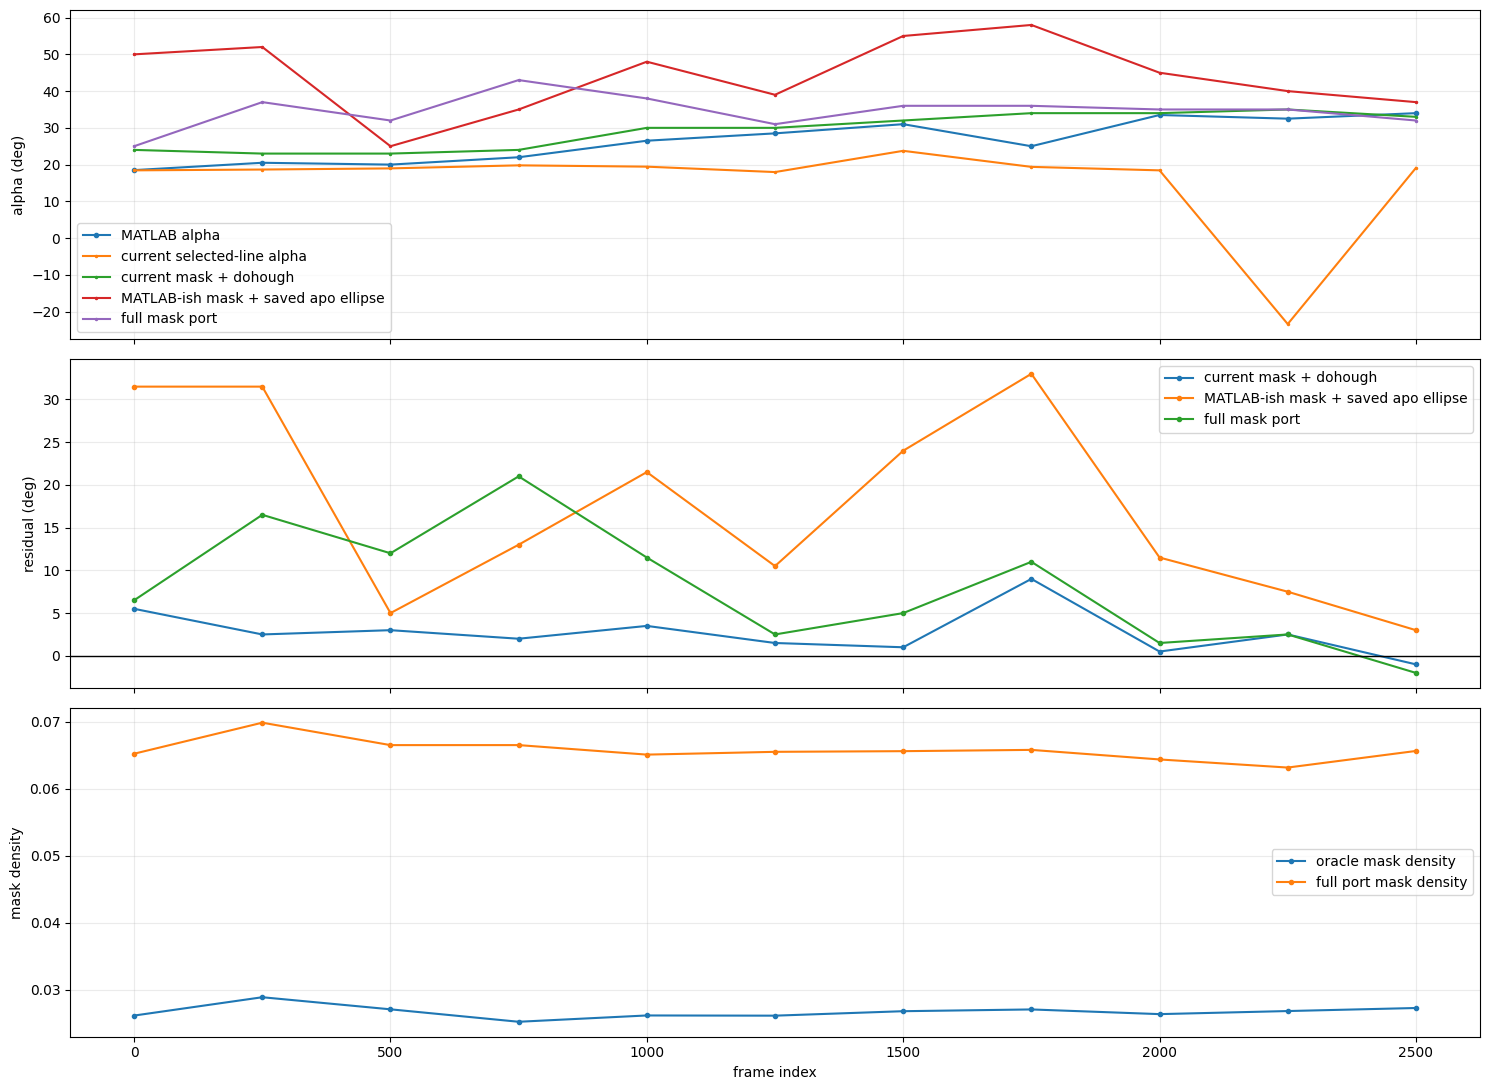

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

axes[0].plot(sample_indices, matlab_alpha_s, "o-", label="MATLAB alpha", markersize=3)
axes[0].plot(sample_indices, current_alpha_s, ".-", label="current selected-line alpha", markersize=3)
axes[0].plot(sample_indices, current_mask_dohough_s, ".-", label="current mask + dohough", markersize=3)
axes[0].plot(sample_indices, oracle_alpha, ".-", label="MATLAB-ish mask + saved apo ellipse", markersize=3)
axes[0].plot(sample_indices, full_port_alpha, ".-", label="full mask port", markersize=3)
axes[0].set_ylabel("alpha (deg)")
axes[0].legend()

axes[1].plot(sample_indices, current_mask_dohough_s - matlab_alpha_s, ".-", label="current mask + dohough")
axes[1].plot(sample_indices, oracle_alpha - matlab_alpha_s, ".-", label="MATLAB-ish mask + saved apo ellipse")
axes[1].plot(sample_indices, full_port_alpha - matlab_alpha_s, ".-", label="full mask port")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("residual (deg)")
axes[1].legend()

axes[2].plot(sample_indices, oracle_density, ".-", label="oracle mask density")
axes[2].plot(sample_indices, full_port_density, ".-", label="full port mask density")
axes[2].set_ylabel("mask density")
axes[2].set_xlabel("frame index")
axes[2].legend()

plt.tight_layout()
plt.show()

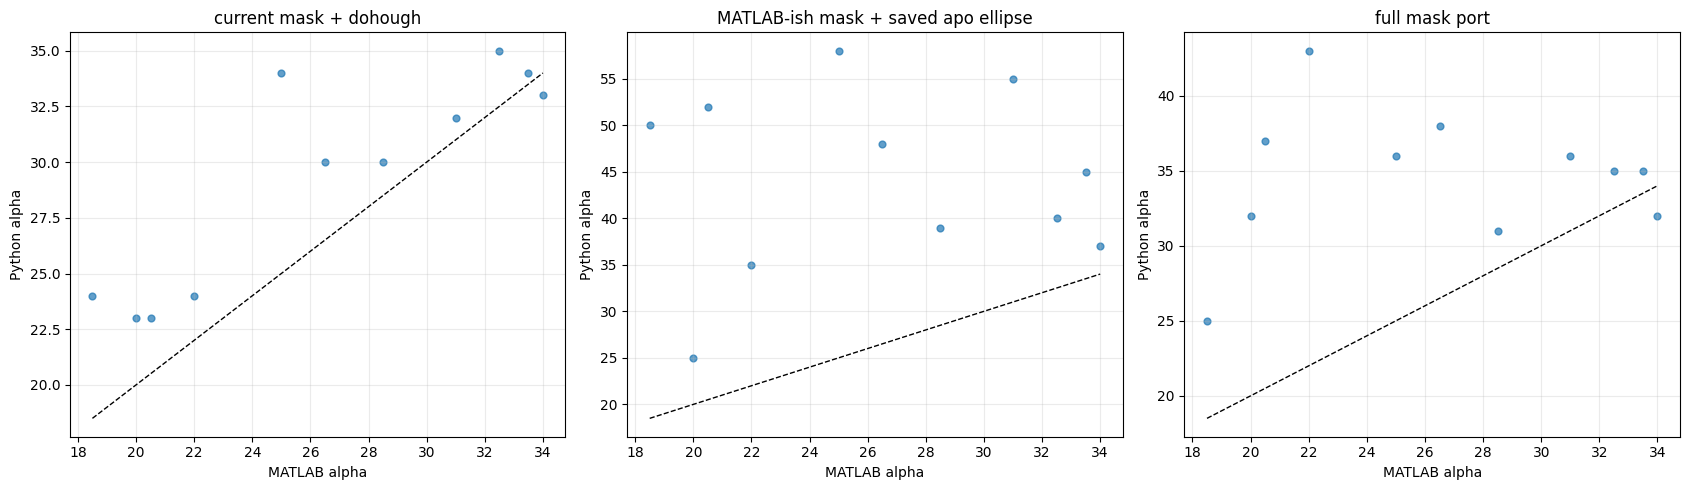

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, values, title in [
    (axes[0], current_mask_dohough_s, "current mask + dohough"),
    (axes[1], oracle_alpha, "MATLAB-ish mask + saved apo ellipse"),
    (axes[2], full_port_alpha, "full mask port"),
]:
    ax.scatter(matlab_alpha_s, values, s=24, alpha=0.7)
    lo = np.nanmin(matlab_alpha_s)
    hi = np.nanmax(matlab_alpha_s)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_xlabel("MATLAB alpha")
    ax.set_ylabel("Python alpha")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Visualize first sampled masks

In [11]:
if first_debug is not None:
    dbg = first_debug
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    axes[0, 0].imshow(dbg["gray"], cmap="gray")
    axes[0, 0].set_title(f"Frame {dbg['frame_idx']} full image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(dbg["oracle_debug"]["fas_filt"], cmap="magma")
    axes[0, 1].set_title("Fascicle Frangi [1,2]")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(dbg["oracle_debug"]["fas_thres"], cmap="gray")
    axes[0, 2].set_title("Adaptive threshold")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(dbg["oracle_mask"], cmap="gray")
    axes[0, 3].set_title(f"Saved-apo ellipse mask alpha={dbg['oracle_result']['alpha']:.1f}")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(dbg["full_debug"]["apo_filt"], cmap="magma")
    axes[1, 0].set_title("Aponeurosis Frangi [18,20]")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(dbg["full_debug"]["super_obj"] | dbg["full_debug"]["deep_obj"], cmap="gray")
    axes[1, 1].set_title("Selected apo objects")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(dbg["full_debug"]["emask"], cmap="gray")
    axes[1, 2].set_title("Ported get_fasMask ellipse")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(dbg["full_mask"], cmap="gray")
    axes[1, 3].set_title(f"Full port mask alpha={dbg['full_result']['alpha']:.1f}")
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Debug images were not cached; set RECOMPUTE=True and rerun the sampled comparison cell to regenerate them.")

Debug images were not cached; set RECOMPUTE=True and rerun the sampled comparison cell to regenerate them.


## Save and decide next correction

The key interpretation:

- If **current mask + dohough** is best, the immediate next production step is to replace alpha estimation first, keeping the existing Python mask initially.
- If **MATLAB-ish mask + saved apo ellipse** improves, the next step is to port the fascicle Frangi/adaptive threshold/ellipse mask into production.
- If **full mask port** is worse, the aponeurosis object detection/adaptive threshold approximation needs refinement before production use.

In [12]:
metrics.to_csv(OUT_DIR / "notebook21_matlab_style_mask_metrics.csv", index=False)

np.savez(
    OUT_DIR / "notebook21_matlab_style_mask_arrays.npz",
    sample_indices=sample_indices,
    matlab_alpha=matlab_alpha_s,
    current_alpha=current_alpha_s,
    current_mask_dohough_alpha=current_mask_dohough_s,
    oracle_mask_alpha=oracle_alpha,
    full_port_mask_alpha=full_port_alpha,
    oracle_density=oracle_density,
    full_port_density=full_port_density,
    full_port_super_mean=full_port_super_mean,
    full_port_deep_mean=full_port_deep_mean,
)

display(metrics)

best_row = metrics.sort_values("mae").iloc[0]
print("Best sampled alpha path:", best_row["comparison"])
print(f"MAE={best_row['mae']:.3f} deg, corr={best_row['corr']:.3f}")
print()
print("Saved:")
print(" -", OUT_DIR / "notebook21_matlab_style_mask_metrics.csv")
print(" -", OUT_DIR / "notebook21_matlab_style_mask_arrays.npz")
print(" -", OUT_SAMPLE)

,comparison,n,bias,mae,rmse,corr
0,current selected-line alpha,11,-11.041044,11.041044,18.651021,-0.313351
1,current mask + dohough alpha,11,2.727273,2.909091,3.735578,0.885918
2,MATLAB-ish mask + saved apo ellipse,11,17.454545,17.454545,20.479480,0.030099
3,full notebook-local filter_usimage port,11,8.000000,8.363636,10.429416,0.091841


Best sampled alpha path: current mask + dohough alpha
MAE=2.909 deg, corr=0.886

Saved:
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook21_matlab_style_mask_metrics.csv
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook21_matlab_style_mask_arrays.npz
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook21_matlab_style_mask_sample_arrays.npz
